# Visualización Gráfica de Datos ECG

Este notebook carga y visualiza gráficamente **todos los 11 archivos CSV** de la sesión del 11 de agosto de 2025 (07:50:23 – 18:27:24).

In [15]:
# Importar bibliotecas necesarias
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Configurar matplotlib para gráficos inline
%matplotlib inline

In [16]:
# Cargar todos los archivos CSV en orden -1 a -11 y combinarlos
import os

csv_files = [f'11-08-2025, 07_50_22-{i}.csv' for i in range(1, 12)]

print(f"Archivos a cargar ({len(csv_files)}):")
for f in csv_files:
    print(f"  {f}")

dfs = [pd.read_csv(os.path.join('..', f)) for f in csv_files]
df = pd.concat(dfs, ignore_index=True)

print(f"\nTotal de filas combinadas: {len(df)}")
print(df.head())
print(df.info())

Archivos a cargar (11):
  11-08-2025, 07_50_22-1.csv
  11-08-2025, 07_50_22-2.csv
  11-08-2025, 07_50_22-3.csv
  11-08-2025, 07_50_22-4.csv
  11-08-2025, 07_50_22-5.csv
  11-08-2025, 07_50_22-6.csv
  11-08-2025, 07_50_22-7.csv
  11-08-2025, 07_50_22-8.csv
  11-08-2025, 07_50_22-9.csv
  11-08-2025, 07_50_22-10.csv
  11-08-2025, 07_50_22-11.csv


C:\Users\Carlo\AppData\Local\Temp\ipykernel_32984\3917795850.py:10: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs = [pd.read_csv(os.path.join('..', f)) for f in csv_files]



Total de filas combinadas: 4972015
        UNIX Timestamp    ECG  HR  RR Marker
0  1754895023517919850 -0.309 NaN NaN    NaN
1  1754895023525603209 -0.307 NaN NaN    NaN
2  1754895023533286568 -0.285 NaN NaN    NaN
3  1754895023540969927 -0.258 NaN NaN    NaN
4  1754895023548653286 -0.250 NaN NaN    NaN
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4972015 entries, 0 to 4972014
Data columns (total 5 columns):
 #   Column          Dtype  
---  ------          -----  
 0   UNIX Timestamp  int64  
 1   ECG             float64
 2   HR              float64
 3   RR              float64
 4   Marker          object 
dtypes: float64(3), int64(1), object(1)
memory usage: 189.7+ MB
None


In [17]:
# Convertir timestamp a datetime
df['UNIX Timestamp'] = pd.to_datetime(df['UNIX Timestamp'], unit='ns')
df.set_index('UNIX Timestamp', inplace=True)

print("DataFrame con timestamp convertido:")
print(df.head())

DataFrame con timestamp convertido:
                                 ECG  HR  RR Marker
UNIX Timestamp                                     
2025-08-11 06:50:23.517919850 -0.309 NaN NaN    NaN
2025-08-11 06:50:23.525603209 -0.307 NaN NaN    NaN
2025-08-11 06:50:23.533286568 -0.285 NaN NaN    NaN
2025-08-11 06:50:23.540969927 -0.258 NaN NaN    NaN
2025-08-11 06:50:23.548653286 -0.250 NaN NaN    NaN


In [18]:
# Usar todos los datos sin filtrar por rango
df_filtered = df

print(f"Total de filas: {len(df_filtered)}")
print(f"Rango temporal: {df_filtered.index.min()} → {df_filtered.index.max()}")
print(f"Duración: {(df_filtered.index.max() - df_filtered.index.min()).total_seconds() / 3600:.2f} horas")

Total de filas: 4972015
Rango temporal: 2025-08-11 06:50:23.517919850 → 2025-08-11 17:27:24.497119254
Duración: 10.62 horas


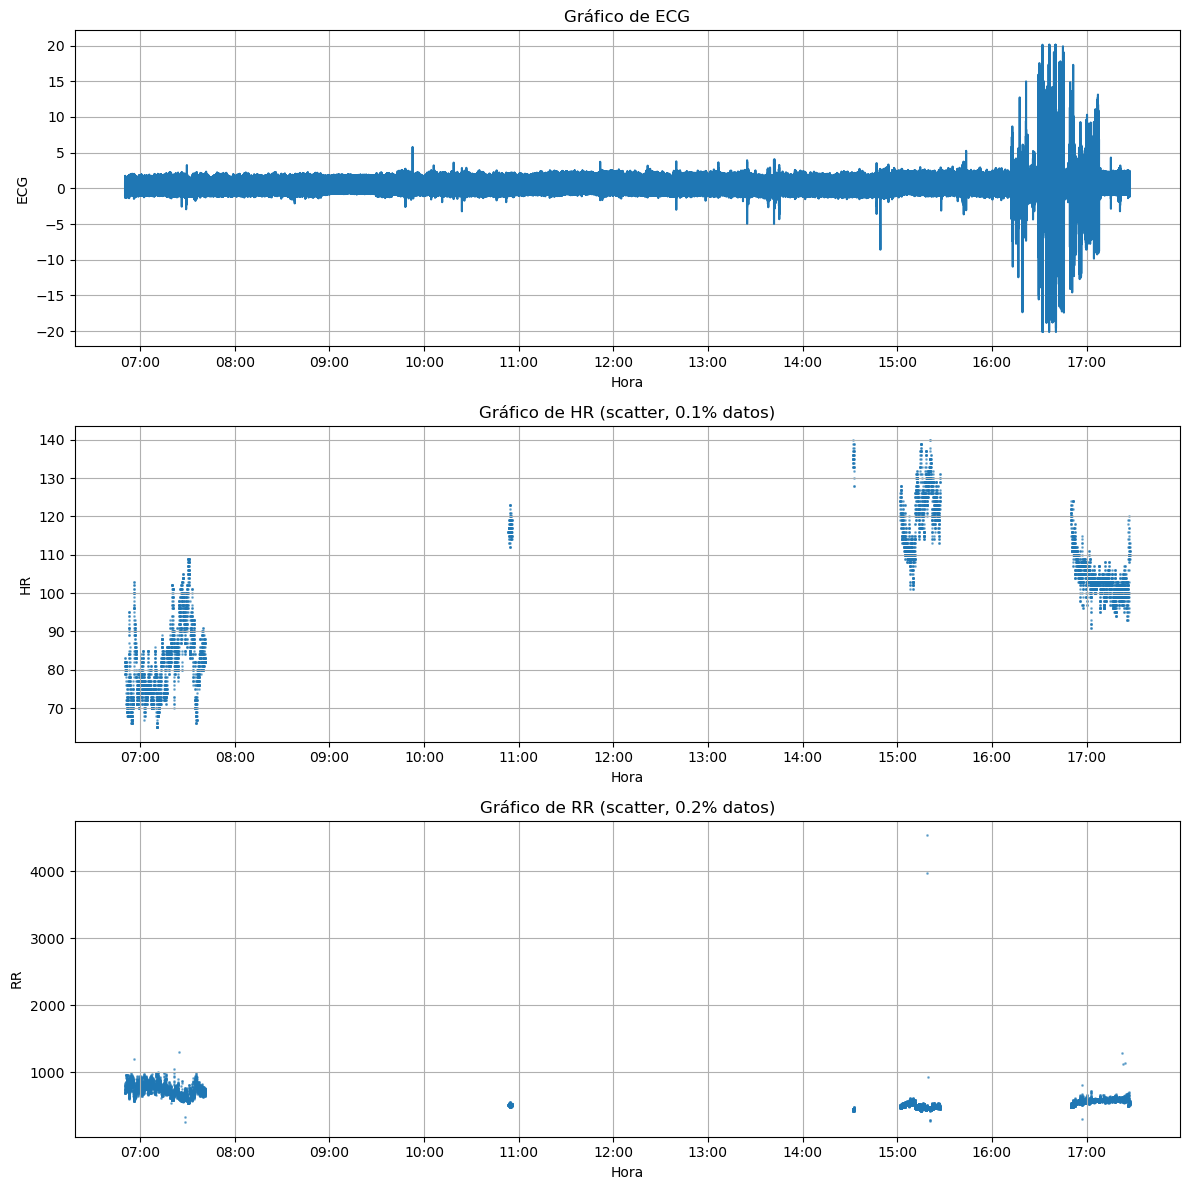

In [19]:
# Graficar todas las columnas numéricas
import matplotlib.dates as mdates

numeric_columns = df_filtered.select_dtypes(include=['float64', 'int64']).columns

fig, axes = plt.subplots(len(numeric_columns), 1, figsize=(12, 4 * len(numeric_columns)))
if len(numeric_columns) == 1:
    axes = [axes]

for i, col in enumerate(numeric_columns):
    # Calcular porcentaje de valores no nulos
    non_null_pct = df_filtered[col].notna().sum() / len(df_filtered) * 100
    
    if non_null_pct < 10:  # Si menos del 10% tiene datos, usar scatter
        axes[i].scatter(df_filtered.index, df_filtered[col], s=1, alpha=0.5)
        axes[i].set_title(f'Gráfico de {col} (scatter, {non_null_pct:.1f}% datos)')
    else:
        axes[i].plot(df_filtered.index, df_filtered[col])
        axes[i].set_title(f'Gráfico de {col}')
    
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    axes[i].set_xlabel('Hora')
    axes[i].set_ylabel(col)
    axes[i].grid(True)

plt.tight_layout()
plt.show()

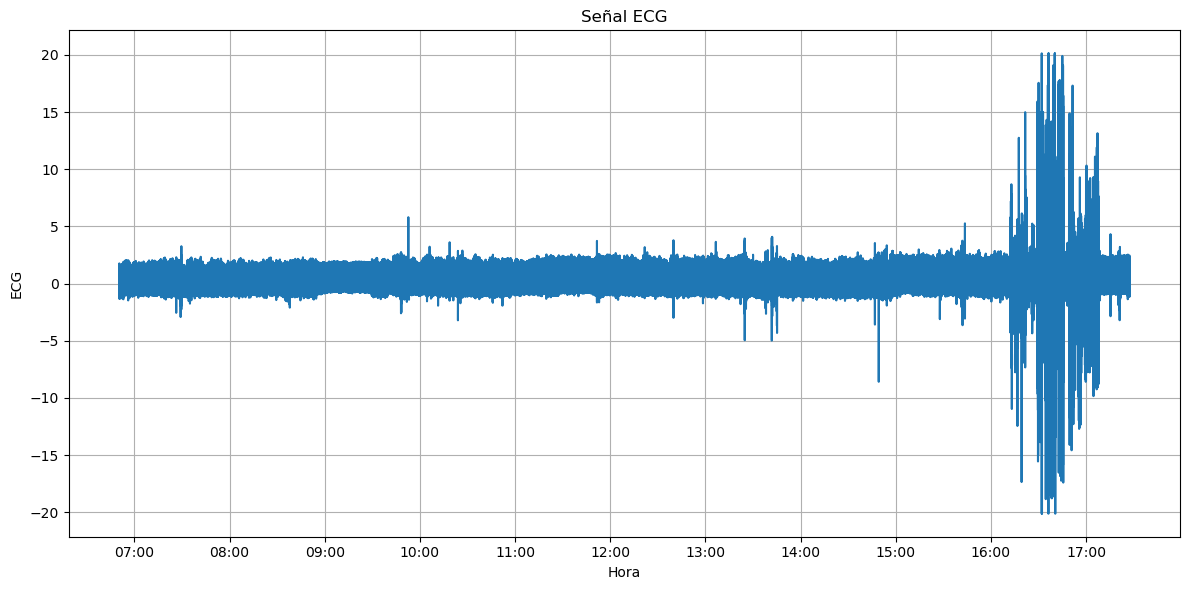

In [20]:
# Graficar ECG específicamente (si existe)
import matplotlib.dates as mdates

if 'ECG' in df_filtered.columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(df_filtered.index, df_filtered['ECG'])
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.set_title('Señal ECG')
    ax.set_xlabel('Hora')
    ax.set_ylabel('ECG')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

In [21]:
# Estadísticas descriptivas del rango filtrado
print("Estadísticas descriptivas del rango filtrado:")
print(df_filtered.describe())

Estadísticas descriptivas del rango filtrado:
                ECG           HR            RR
count  4.972015e+06  6924.000000  11410.000000
mean  -3.010383e-02    97.971548    613.558370
std    6.761670e-01    17.579096    127.511436
min   -2.013300e+01    65.000000    254.000000
25%   -2.080000e-01    82.000000    527.000000
50%   -1.100000e-01   101.000000    585.000000
75%    1.900000e-02   110.000000    690.000000
max    2.013000e+01   140.000000   4538.000000
